In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [49]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
data = data.drop(['customerID'], axis = 1)

In [52]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [53]:
data.drop(labels=data[data['TotalCharges'].isna()].index, inplace=True, axis=0) #drop NaN TotalCharges (11)

In [54]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
data[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


Visualization


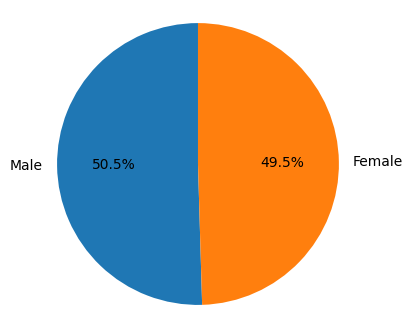

In [55]:
gender_counts = data['gender'].value_counts()

plt.figure(figsize=(4, 4))


plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)

plt.axis('equal')
plt.show()

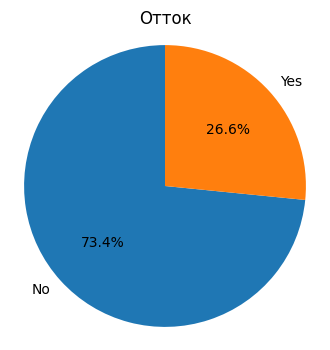

In [56]:
churn_counts = data['Churn'].value_counts()
plt.figure(figsize=(4, 4))


plt.pie(churn_counts.values,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title('Отток')
plt.axis('equal')
plt.show()

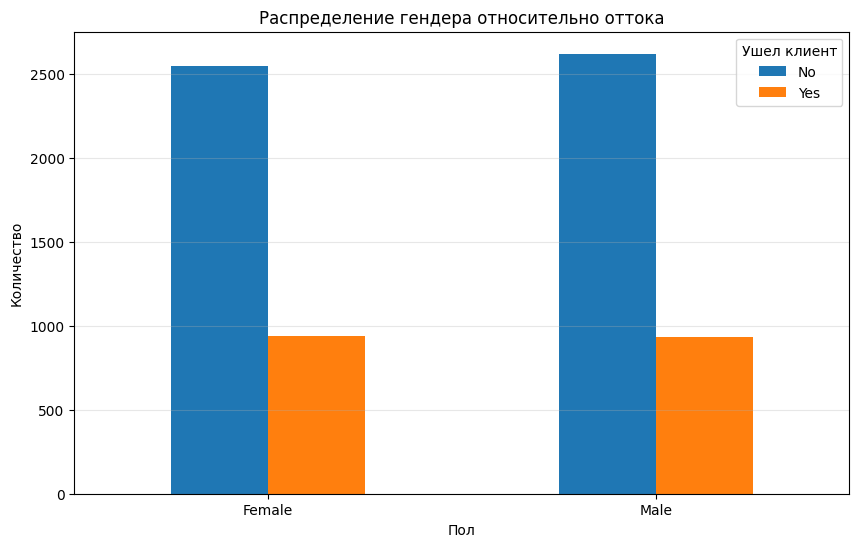

In [57]:
cross_tab_gen = pd.crosstab(data['gender'], data['Churn'])

cross_tab_gen.plot(kind='bar', figsize=(10, 6))
plt.title('Распределение гендера относительно оттока')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.legend(title='Ушел клиент')
plt.grid(axis='y', alpha=0.3)
plt.show()

Пол не влияет на отток


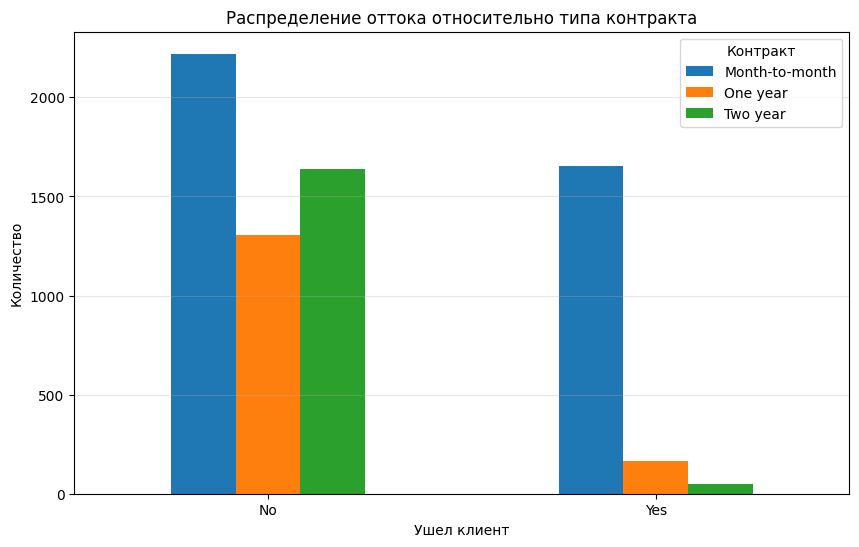

In [58]:
cross_tab_chrn = pd.crosstab(data['Churn'], data['Contract'])

cross_tab_chrn.plot(kind='bar',figsize=(10,6))
plt.title('Распределение оттока относительно типа контракта')
plt.xlabel('Ушел клиент')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.legend(title='Контракт')
plt.grid(axis='y', alpha=0.3)
plt.show()


Около 75% клиентов с помесячным контрактом решили отказаться от услуг по сравнению с 13% клиентов с годовым контрактом и 3% с двухлетним контрактом.

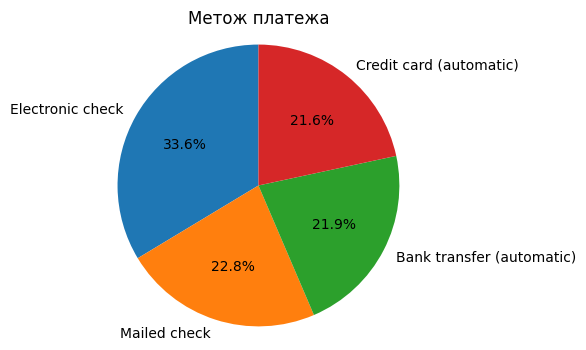

In [59]:
payment_count = data['PaymentMethod'].value_counts()
plt.figure(figsize=(4, 4))


plt.pie(payment_count.values,
        labels=payment_count.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title('Метож платежа')
plt.axis('equal')
plt.show()

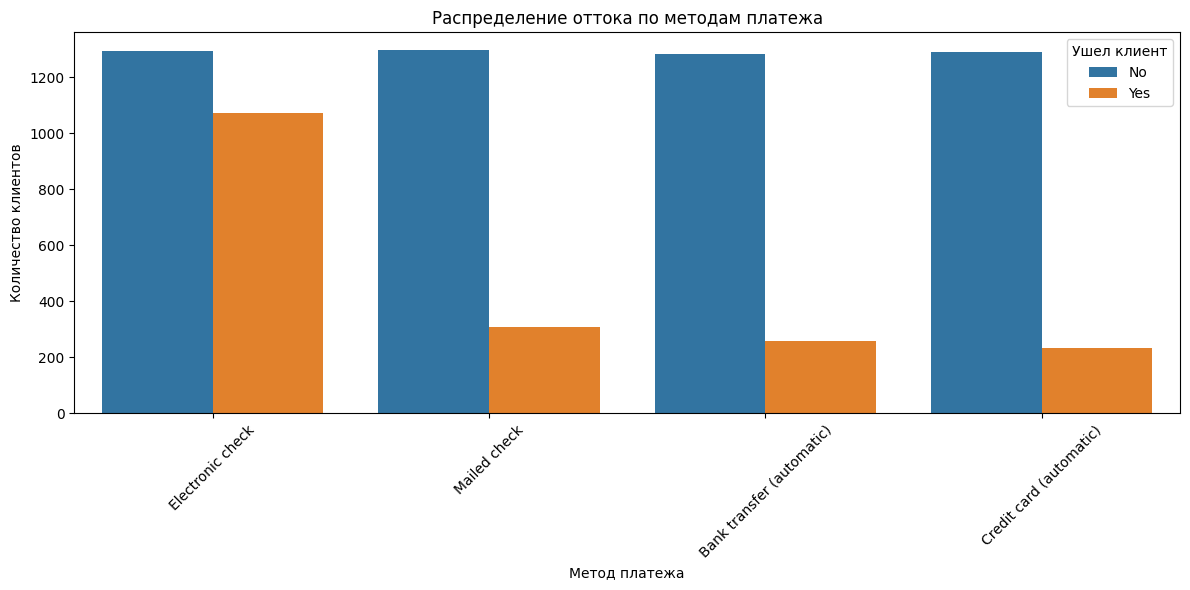

In [60]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='PaymentMethod', hue='Churn')
plt.title('Распределение оттока по методам платежа')
plt.xlabel('Метод платежа')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.legend(title='Ушел клиент')
plt.tight_layout()
plt.show()


Большинство клиентов, съехавших из квартиры, использовали электронные чеки в качестве способа оплаты.
Клиенты, выбравшие автоматический перевод на кредитную карту или автоматический банковский перевод и отправку чека по почте, реже съезжали.

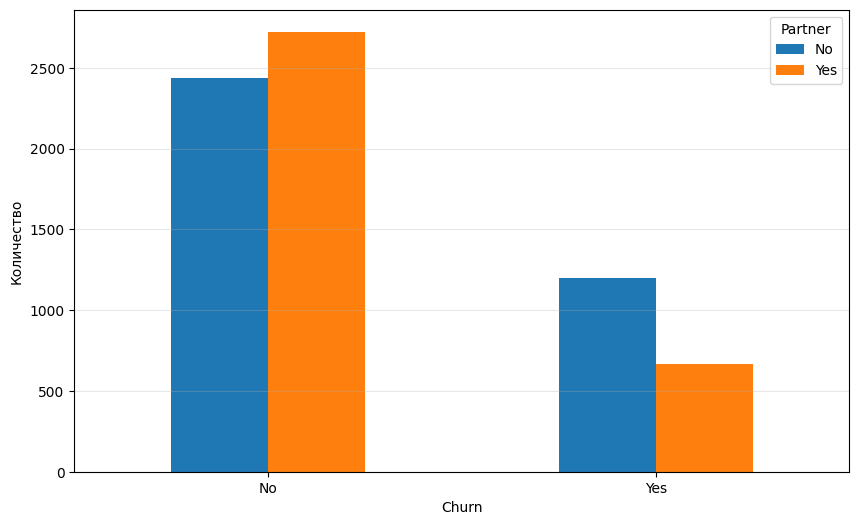

In [61]:
cross_tab_partners = pd.crosstab(data['Churn'], data['Partner'] )

cross_tab_partners.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Клиенты без партнера чаще уходят


<Axes: xlabel='Churn', ylabel='count'>

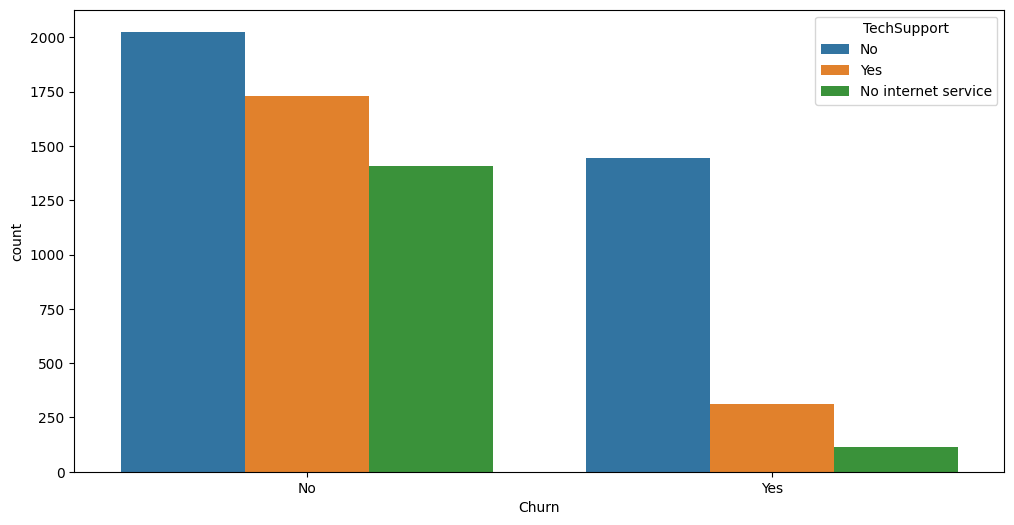

In [62]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Churn', hue='TechSupport')

Клиенты, у которых нет технической поддержки, скорее всего, перейдут к другому поставщику услуг.


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

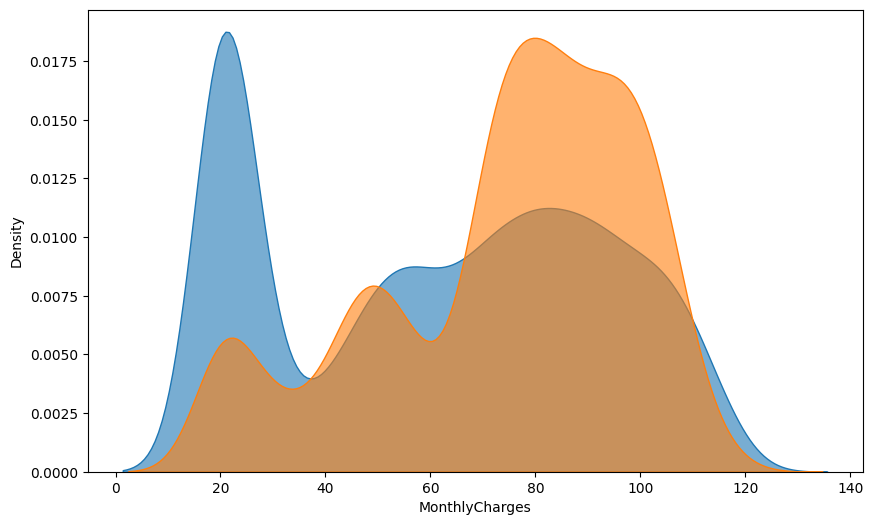

In [63]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data[data['Churn'] == 'No'],
            x='MonthlyCharges',
            label='No Churn',
            fill=True,
            alpha=0.6,
            common_norm=False)

sns.kdeplot(data=data[data['Churn'] == 'Yes'],
            x='MonthlyCharges',
            label='Churn',
            fill=True,
            alpha=0.6,
            common_norm=False)

Клиенты с более высокими ежемесячными платежами также более склонны к оттоку.

<Axes: >

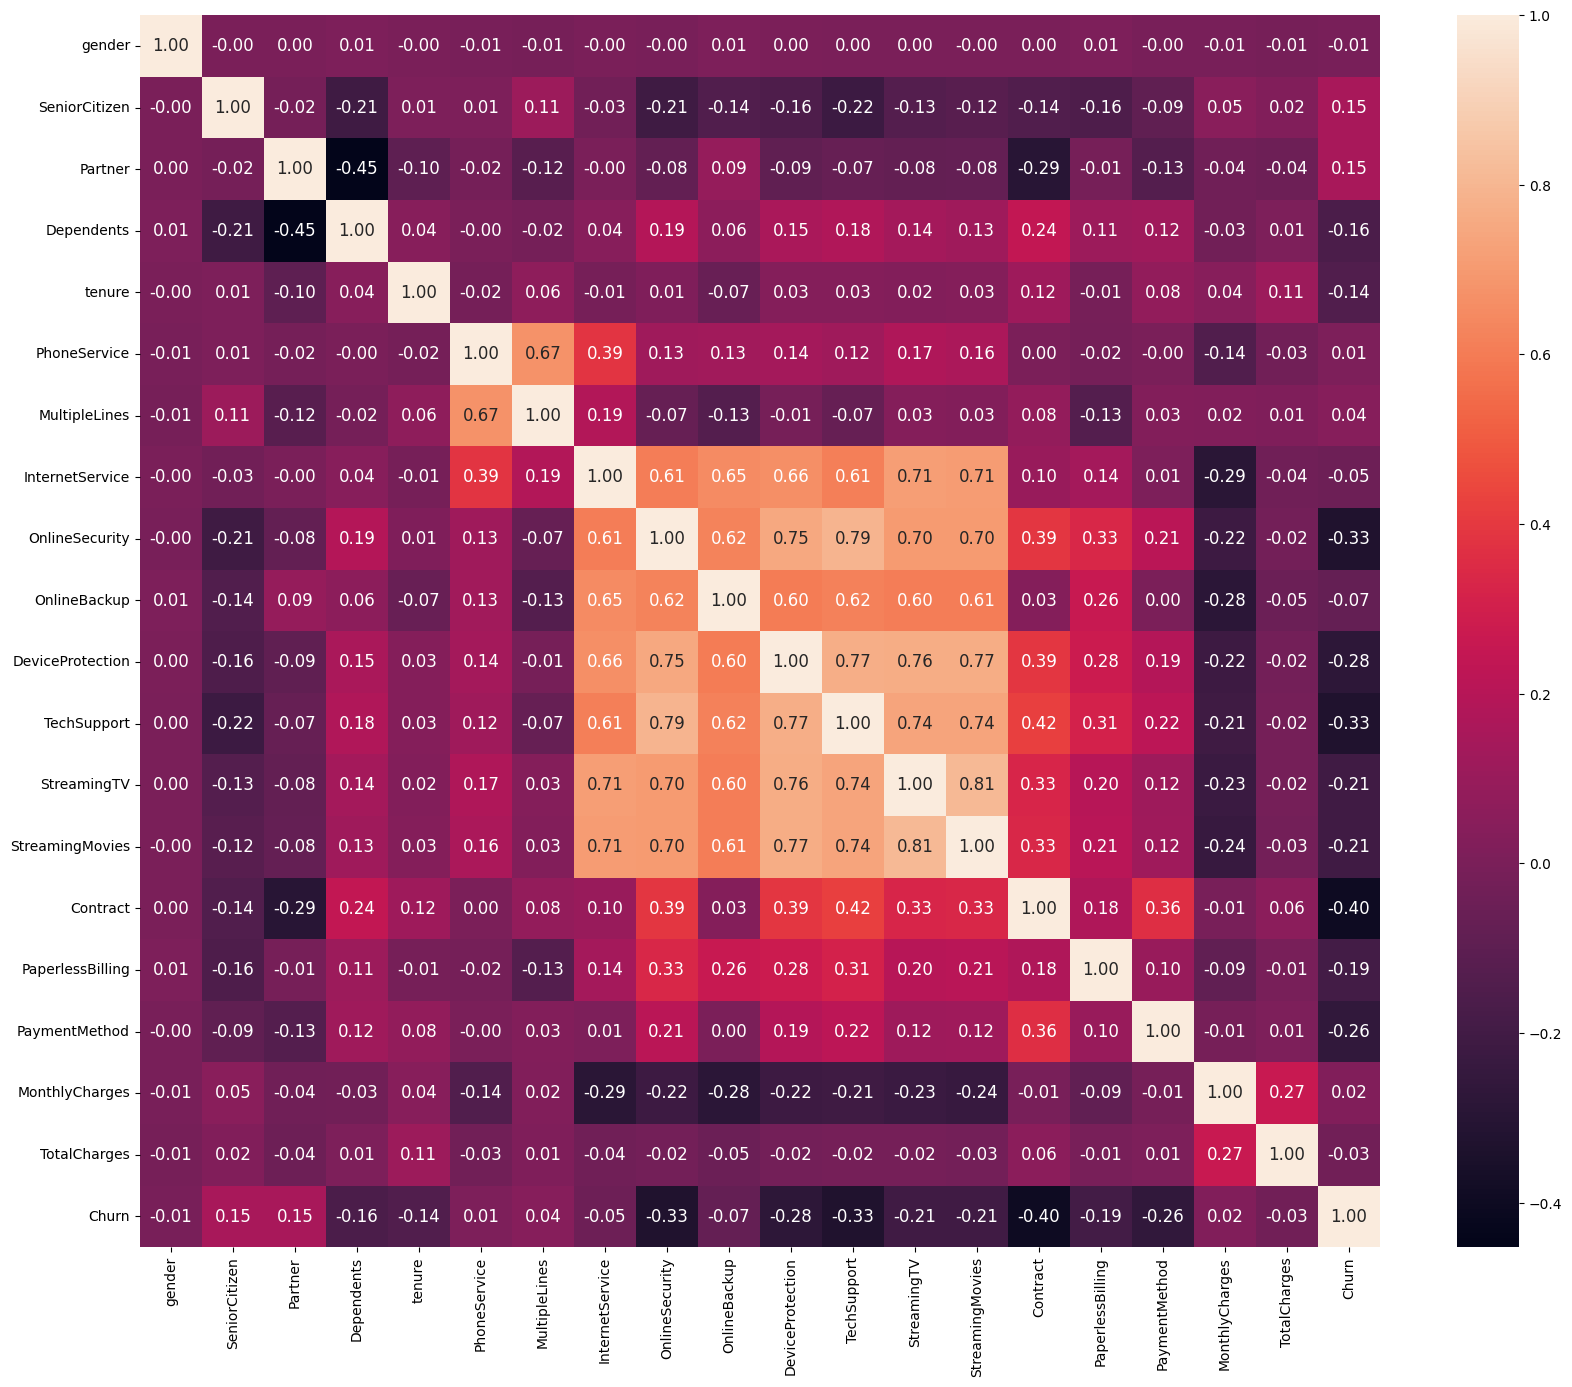

In [64]:
plt.figure(figsize=(20, 16))

corr = data.apply(lambda x: pd.factorize(x)[0]).corr()
sns.heatmap(corr,
            fmt='.2f',
            annot=True,
            annot_kws={'size': 12})

Preprocessing


In [65]:
from sklearn.preprocessing import LabelEncoder

def object_to_int(dataSeries):
  if dataSeries.dtype =='object':
    dataSeries = LabelEncoder().fit_transform(dataSeries)
  return dataSeries

In [ ]:


data = data.apply(lambda x: object_to_int(x))
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [67]:
plt.figure(figsize=(14,7))
data.corr()['Churn'].sort_values(ascending = False)

,Churn
Churn,1.000000
MonthlyCharges,0.192858
PaperlessBilling,0.191454
SeniorCitizen,0.150541
PaymentMethod,0.107852
MultipleLines,0.038043
PhoneService,0.011691
gender,-0.008545
StreamingTV,-0.036303
StreamingMovies,-0.038802


<Figure size 1400x700 with 0 Axes>

In [68]:
X = data.drop(columns=['Churn'])
y = data['Churn'].values

In [69]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 14, stratify=y)



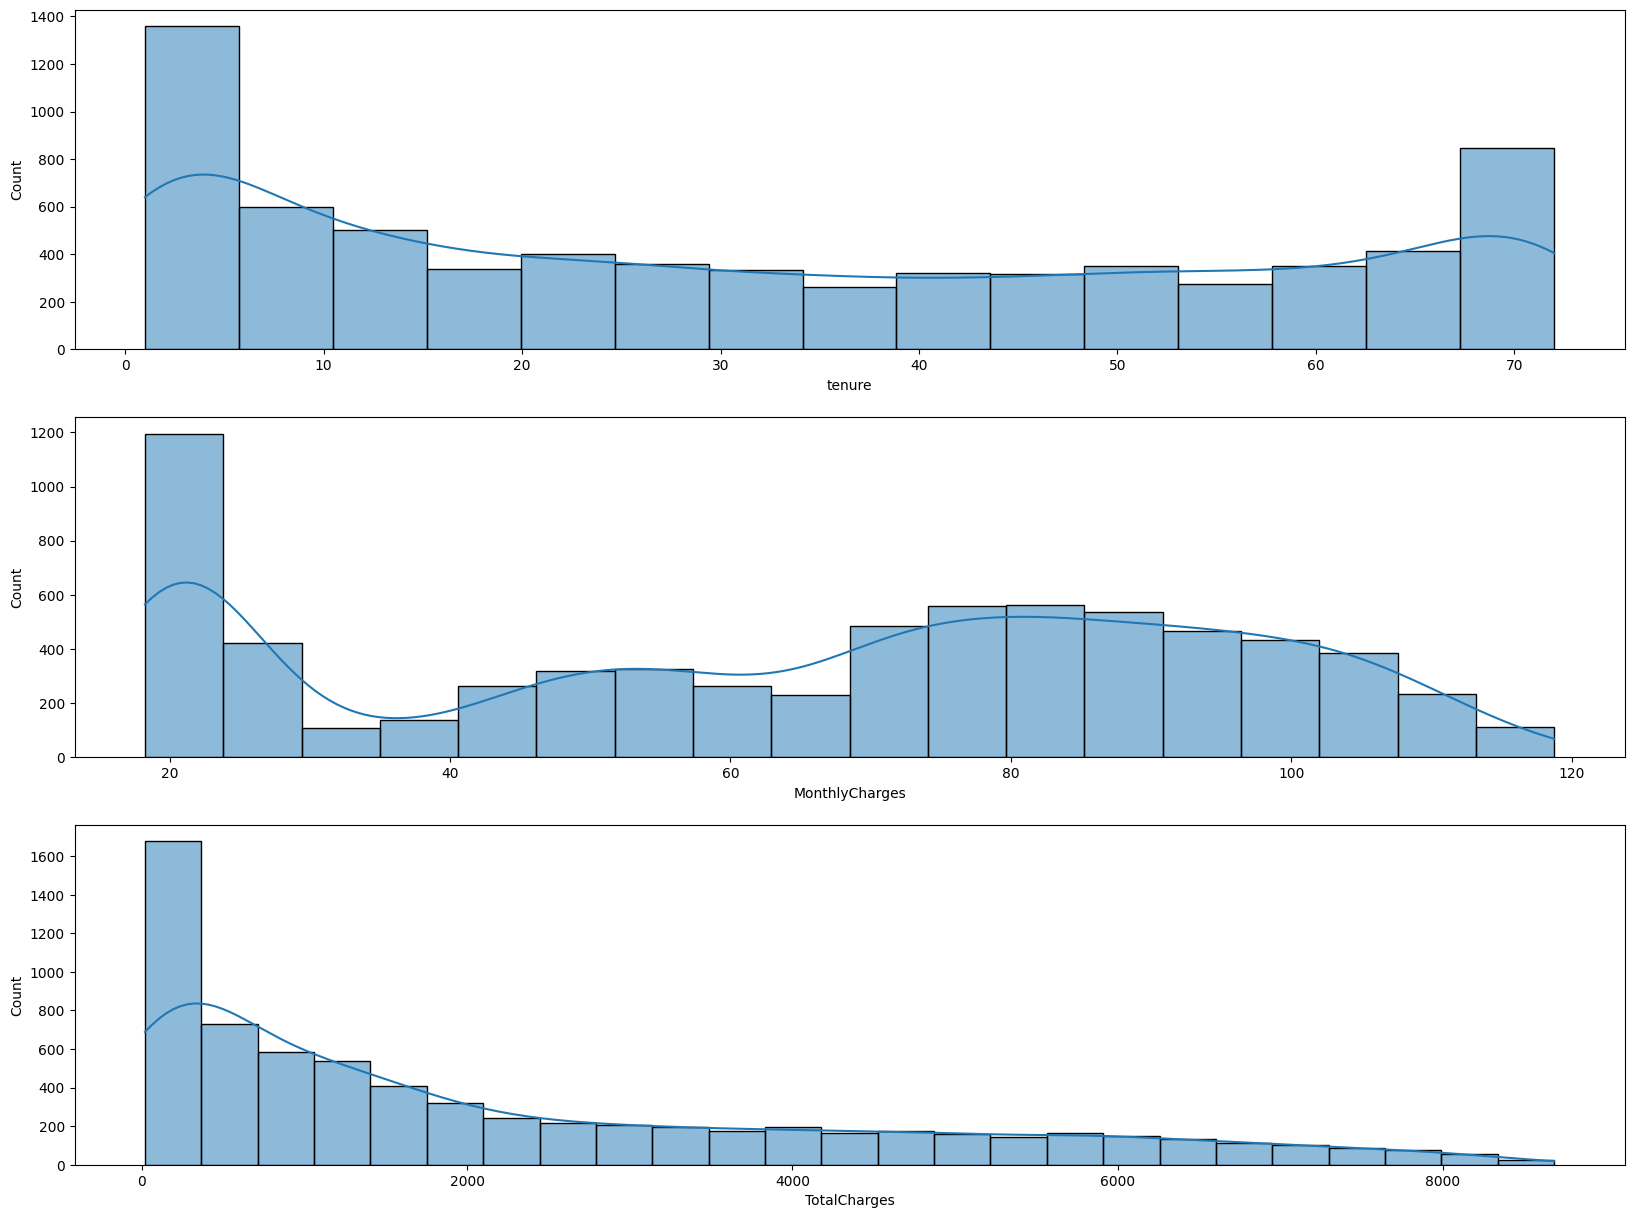

In [70]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(20,5*len(num_cols)))

for i, col in enumerate(num_cols):
  sns.histplot(data=data, x=col, kde=True, ax=axes[i])

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

from sklearn.metrics import classification_report

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGB':XGBClassifier(),

}

from sklearn.metrics import precision_recall_fscore_support

results = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    results[name] = {'Precision': precision, 'Recall': recall, 'F1': f1}


for name, metrics in results.items():
    print(f"{name}: Precision={metrics['Precision']:.3f}, Recall={metrics['Recall']:.3f}, F1={metrics['F1']:.3f}")

Logistic Regression: Precision=0.532, Recall=0.800, F1=0.639
SVM: Precision=0.546, Recall=0.770, F1=0.639
Decision Tree: Precision=0.474, Recall=0.592, F1=0.526
Random Forest: Precision=0.586, Recall=0.649, F1=0.616
Gradient Boosting: Precision=0.554, Recall=0.770, F1=0.644
Naive Bayes: Precision=0.514, Recall=0.788, F1=0.622
XGB: Precision=0.552, Recall=0.636, F1=0.591


Байсовский классификатор


In [73]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
}

from sklearn.model_selection import StratifiedKFold

stratified_cv = StratifiedKFold(shuffle=True, random_state=14)

In [74]:
grid_Bayes = GridSearchCV(
    GaussianNB (),
    param_grid = param_grid,
    cv = stratified_cv
)

grid_Bayes.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=14, shuffle=True),
             estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]})

In [75]:
y_proba_Bayes = grid_Bayes.predict_proba(X_test)[:,1]
y_pred_Bayes = (y_proba_Bayes>0.438).astype(int)

In [76]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_Bayes)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-7)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Лучший порог: {best_threshold:.3f}")

Лучший порог: 0.565


In [77]:
print(classification_report(y_test, y_pred_Bayes))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.53      0.76      0.63       561

    accuracy                           0.76      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.76      0.77      2110



In [78]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_Bayes)
roc_auc

np.float64(0.7590475828807959)

In [79]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_pred_Bayes)
pr_auc

np.float64(0.46707073804329036)

In [80]:
ratio = len(y_train[y_train==0])/len(y_train[y_train==1])

In [81]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1, ratio, ratio*1.5]  # ratio = count_0 / count_1
}

In [82]:
search = RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=param,
    n_iter=20,  # сколько комбинаций проверить
    cv=stratified_cv,
    scoring='f1_macro',
    n_jobs=-1
)

In [83]:
search.fit(X_train_resampled, y_train_resampled)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=14, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [1,
                                                             2.7629969418960245,
                                                             4.144495412844037],
                                        'subsample': [0.8, 0.9, 1.0]},
                   scoring='f1_macro')

In [84]:
search.best_params_

{'subsample': 0.9,
 'scale_pos_weight': 1,
 'n_estimators': 200,
 'max_depth': 9,
 'learning_rate': 0.05,
 'gamma': 0,
 'colsample_bytree': 0.9}

In [85]:
y_proba_xgb = search.predict_proba(X_test)[:,1]
y_pred_xgb = search.predict(X_test)

In [86]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1549
           1       0.57      0.67      0.61       561

    accuracy                           0.78      2110
   macro avg       0.72      0.74      0.73      2110
weighted avg       0.79      0.78      0.78      2110



In [87]:
# param = {
#     'n_estimators': [300,500,700,1000],
#     'max_depth': [7, 9,15],
#     'learning_rate': [0.01, 0.05, 0.005],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9,],
#     'gamma': [ 0.1, 0.2],
#     'scale_pos_weight': [1, ratio, ratio*1.5]  # ratio = count_0 / count_1
# }


# grid_xgb = GridSearchCV(
#     estimator=XGBClassifier(),
#     param_grid=param,
#     cv=stratified_cv,
#     scoring='f1_macro',
#     n_jobs=-1

# )

# grid_xgb.fit(X_train,y_train)
# y_pred_xgb = search.predict(X_test)
# print(classification_report(y_test, y_pred_xgb))

{'colsample_bytree': 0.8,
 'gamma': 0.1,
 'learning_rate': 0.01,
 'max_depth': 7,
 'n_estimators': 300,
 'scale_pos_weight': 2.7629969418960245,
 'subsample': 0.9}

In [88]:
xgb =  XGBClassifier(
    colsample_bytree=0.8,
    gamma=0.1,
    learning_rate=0.01,
    max_depth=10,
    subsample = 0.9,
    scale_pos_weight =  2,
    n_estimators=700,

)

In [89]:
xgb.fit(X_train_resampled,y_train_resampled)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

from sklearn.metrics import precision_recall_curve
import numpy as np


precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.nanargmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Оптимальный порог: {best_threshold:.3f}")


y_pred_xgb = (y_proba_xgb > best_threshold).astype(int)
print(classification_report(y_test, y_pred_xgb))


Оптимальный порог: 0.546
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1549
           1       0.56      0.73      0.63       561

    accuracy                           0.78      2110
   macro avg       0.73      0.76      0.74      2110
weighted avg       0.80      0.78      0.78      2110



Text(0.5, 36.72222222222221, 'Predicted')

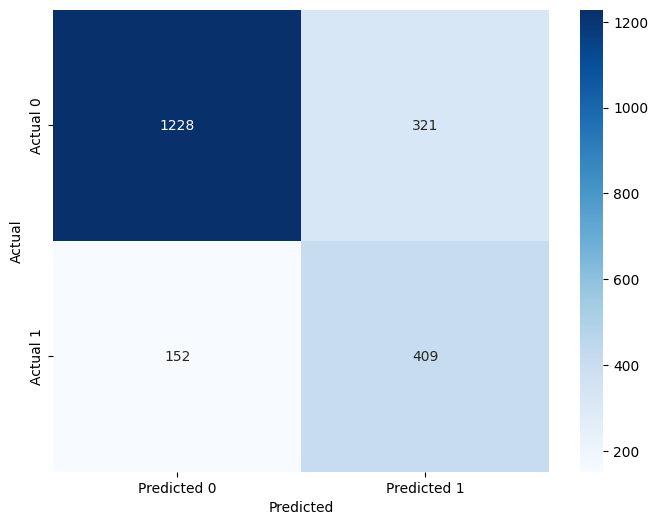

In [91]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_xgb)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [90]:
importance = xgb.feature_importances_
feature_names = X_train.columns

# Сортировка по важности
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance)

             feature  importance
14          Contract    0.632480
8     OnlineSecurity    0.078193
7    InternetService    0.024608
5       PhoneService    0.021998
4             tenure    0.021769
11       TechSupport    0.020351
13   StreamingMovies    0.019181
3         Dependents    0.018700
17    MonthlyCharges    0.017367
16     PaymentMethod    0.015633
12       StreamingTV    0.015583
9       OnlineBackup    0.015505
10  DeviceProtection    0.015143
2            Partner    0.014752
18      TotalCharges    0.014687
0             gender    0.014388
6      MultipleLines    0.013752
1      SeniorCitizen    0.013176
15  PaperlessBilling    0.012733


Most importat feature - Contract

In [2]:
import json
model = {
    'type': 'XGBClassifier',
    'params':{
        'colsample_bytree':0.8,
        'gamma':0.1,
        'learning_rate':0.01,
        'max_depth':10,
        'subsample' :0.9,
        'scale_pos_weight':2,
        'n_estimators':700,
    }
}

with open('../config/model.json', 'w') as f:
    json.dump(model, f, indent=4)